In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier


from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [2]:
iris = load_iris()


In [3]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [4]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [5]:
iris.data

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [10]:
X, y = load_iris(return_X_y=True, as_frame=True)
columns = ['sepal length (cm)', 'sepal width (cm)']
X = X[columns]
print(X.columns)

Index(['sepal length (cm)', 'sepal width (cm)'], dtype='str')


In [16]:
#print(X.info())
#print(X.head())
print(y.info())
print(y.head())

<class 'pandas.Series'>
RangeIndex: 150 entries, 0 to 149
Series name: target
Non-Null Count  Dtype
--------------  -----
150 non-null    int64
dtypes: int64(1)
memory usage: 1.3 KB
None
0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64


In [17]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=40)   
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.3, random_state=36)

EDA

['0', '1', '2']


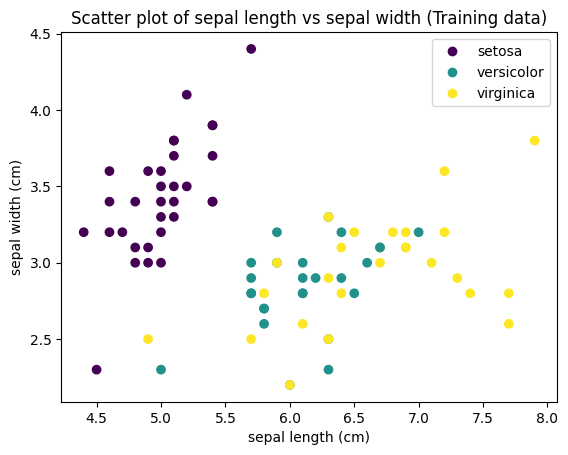

In [30]:
classes = ['setosa', 'versicolor', 'virginica']
scatter = plt.scatter(X_train['sepal length (cm)'], X_train['sepal width (cm)'], c=y_train, cmap='viridis')

#Just trying out what scatter.legend_elements() returns, to see if I can get the class labels from it
handles, labels = scatter.legend_elements()
clean_labels = [lbl.strip('$').replace('\\mathdefault{', '').replace('}', '')
                for lbl in labels]
print(clean_labels)

plt.xlabel('sepal length (cm)')
plt.ylabel('sepal width (cm)')
plt.title('Scatter plot of sepal length vs sepal width (Training data)')
plt.legend(handles=scatter.legend_elements()[0], labels=classes)
plt.show()

In [33]:
print(X_train.head())
print(y_train.head())
print(y_train.tail())

    sepal length (cm)  sepal width (cm)
72                6.3               2.5
62                6.0               2.2
74                6.4               2.9
19                5.1               3.8
93                5.0               2.3
72    1
62    1
74    1
19    0
93    1
Name: target, dtype: int64
10     0
110    2
4      0
30     0
128    2
Name: target, dtype: int64


Train 2 different models

In [35]:
y_train.value_counts()

target
0    32
1    26
2    26
Name: count, dtype: int64

In [34]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_val_pred_log_reg = log_reg.predict(X_val)
print("Logistic Regression Classification Report:")
print(classification_report(y_val, y_val_pred_log_reg, target_names=classes))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

      setosa       0.91      1.00      0.95        10
  versicolor       0.53      0.67      0.59        12
   virginica       0.70      0.50      0.58        14

    accuracy                           0.69        36
   macro avg       0.71      0.72      0.71        36
weighted avg       0.70      0.69      0.69        36



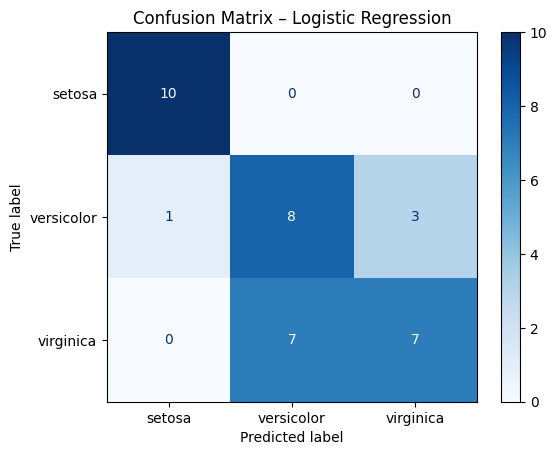

In [36]:
#Confusion matrix for logistic regression

cm = confusion_matrix(y_val, y_val_pred_log_reg)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix – Logistic Regression")
plt.show()


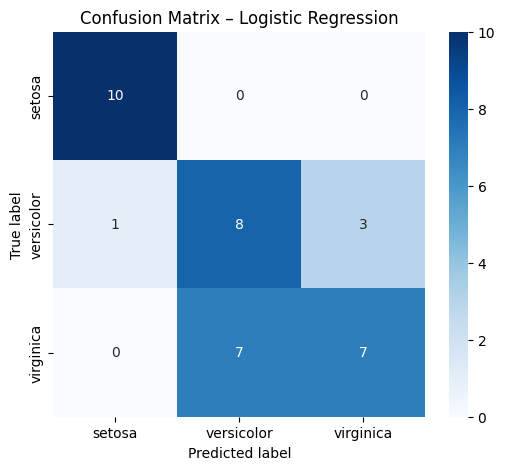

In [37]:
import seaborn as sns

cm_df = pd.DataFrame(cm, index=classes, columns=classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix – Logistic Regression")
plt.show()
